In [1]:
import pandas as pd

df = pd.read_csv("results/partial/scalabilityApproaches_all_methods_v1_partial.csv")

In [140]:
from pathlib import Path
import pandas as pd

df = pd.DataFrame()
for x in Path("results/remote").glob("*K*_n*.csv"):
    with open(x) as f:
        if len(f.readlines()):
            df = pd.concat([df, pd.read_csv(x)])

In [145]:
for x in df.columns:
    print(x)

risk
K
n
seed
gamma
alpha
epsilon
epsilon_scr
kappa
tau
max_candidates
n_screen_starts
n_support_starts
screen_maxiter
support_maxiter
stochastic_max_iter
stochastic_minibatch_size
methods
mcp_success
mcp_time_s
mcp_eta
mcp_regret1
mcp_regret2
mcp_has_profile
mcp_error
mcp_solver
mcp_candidate_index
mcp_support_eta
mcp_screen_eta
mcp_support_violation
mcp_residual_norm
mcp_objective
mcp_iterations
mcp_best_certificate_eta
screened_dual_success
screened_dual_time_s
screened_dual_eta
screened_dual_regret1
screened_dual_regret2
screened_dual_has_profile
screened_dual_error
screened_dual_solver
screened_dual_candidate_index
screened_dual_support_eta
screened_dual_screen_eta
screened_dual_support_violation
screened_dual_residual_norm
screened_dual_objective
screened_dual_iterations
screened_dual_best_certificate_eta
action_dual_success
action_dual_time_s
action_dual_eta
action_dual_regret1
action_dual_regret2
action_dual_has_profile
action_dual_error
action_dual_solver
action_dual_candidate

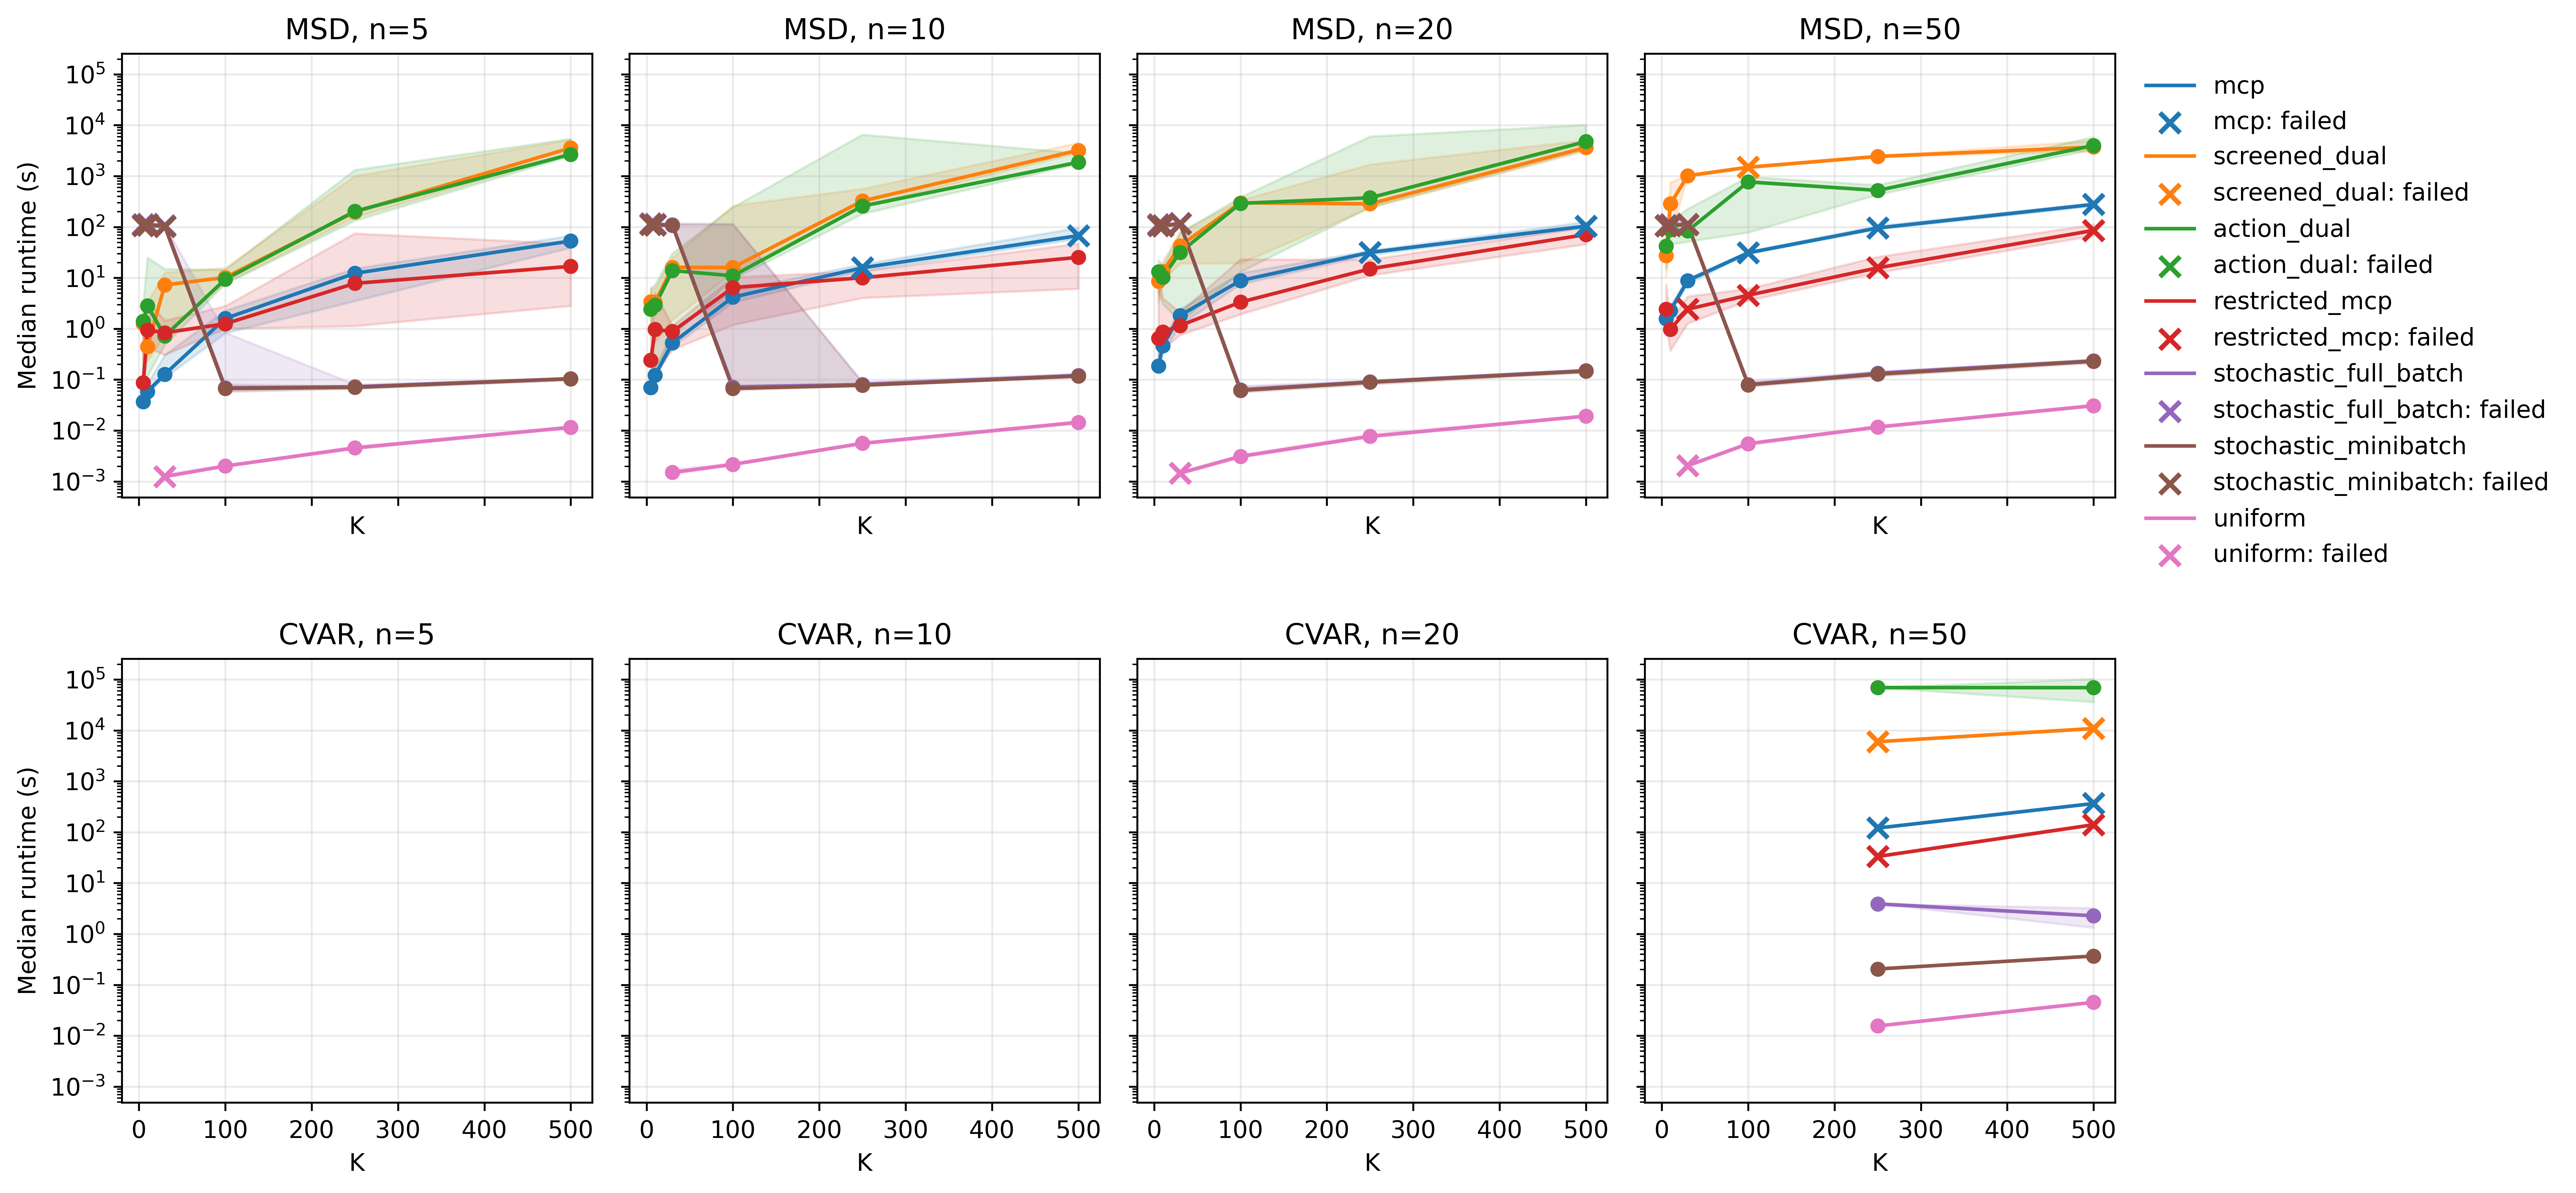

In [146]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_time_median": (f"{method}_time_s", "median"),
                    f"{method}_time_q25": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_time_q75": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_time_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_time_q25"],
                method_df[f"{method}_time_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_time_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_time_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median runtime (s)")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

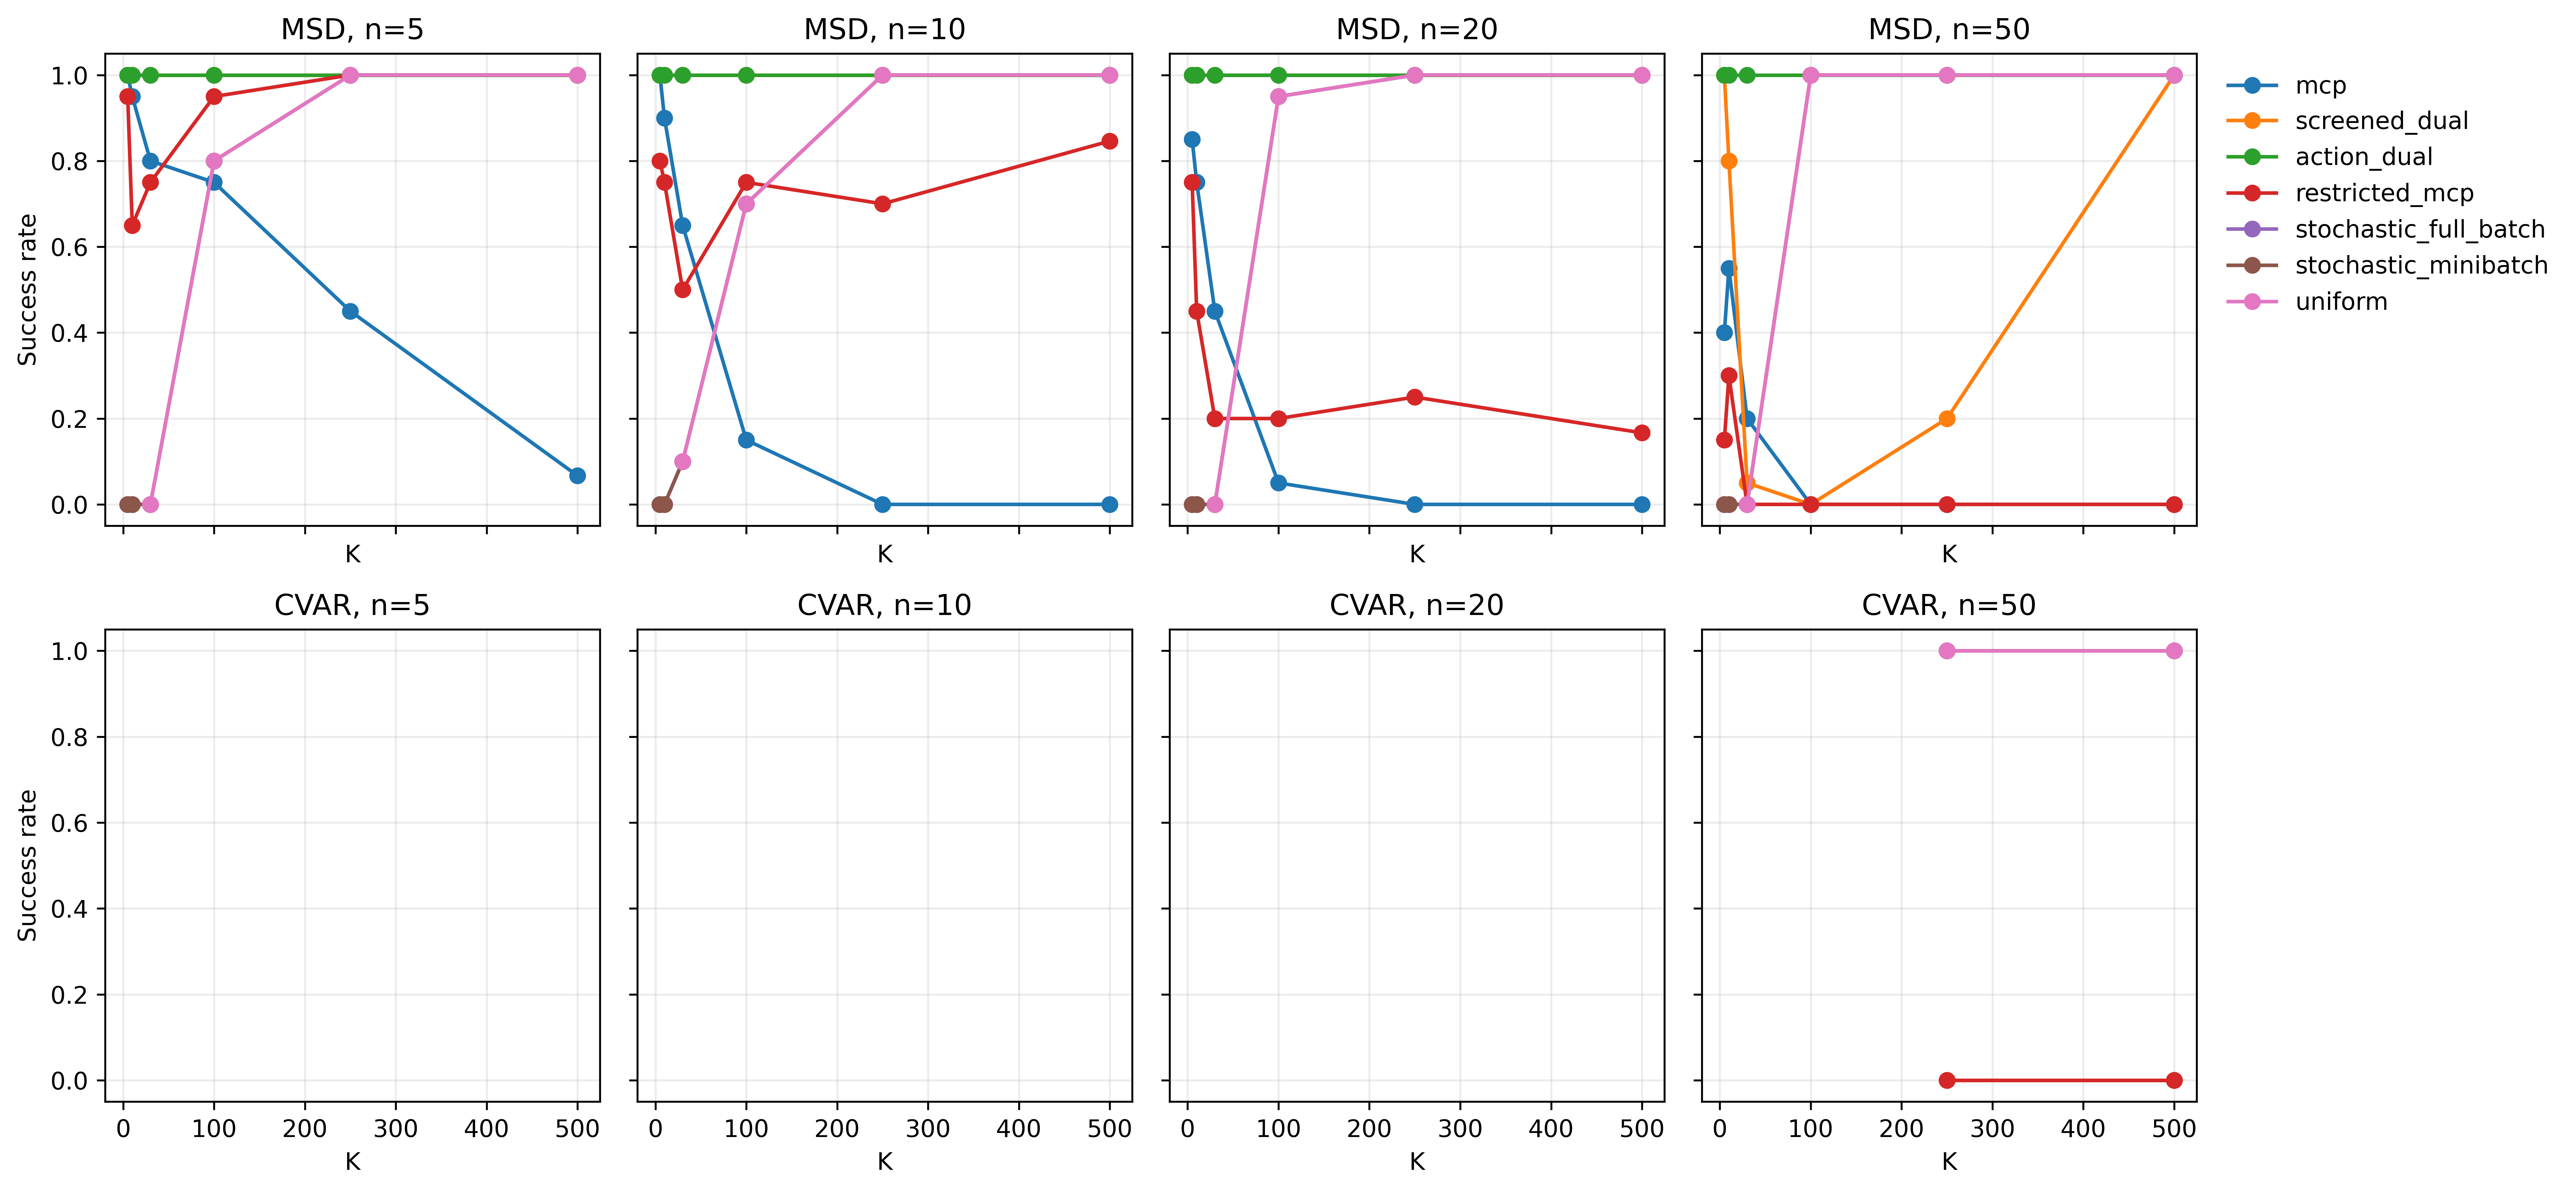

In [147]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)]
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        )

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = (
                method_s.groupby("K", as_index=False)
                .agg(
                    **{
                        f"{method}_reps": ("seed", "count"),
                        f"{method}_succ_n": (f"{method}_success", "sum"),
                    }
                )
                .sort_values("K")
            )

            if method_df.empty:
                continue

            method_df[f"{method}_succ_rate"] = (
                method_df[f"{method}_succ_n"] / method_df[f"{method}_reps"]
            )

            ax.plot(
                method_df["K"],
                method_df[f"{method}_succ_rate"],
                "o-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )

        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel("Success rate")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

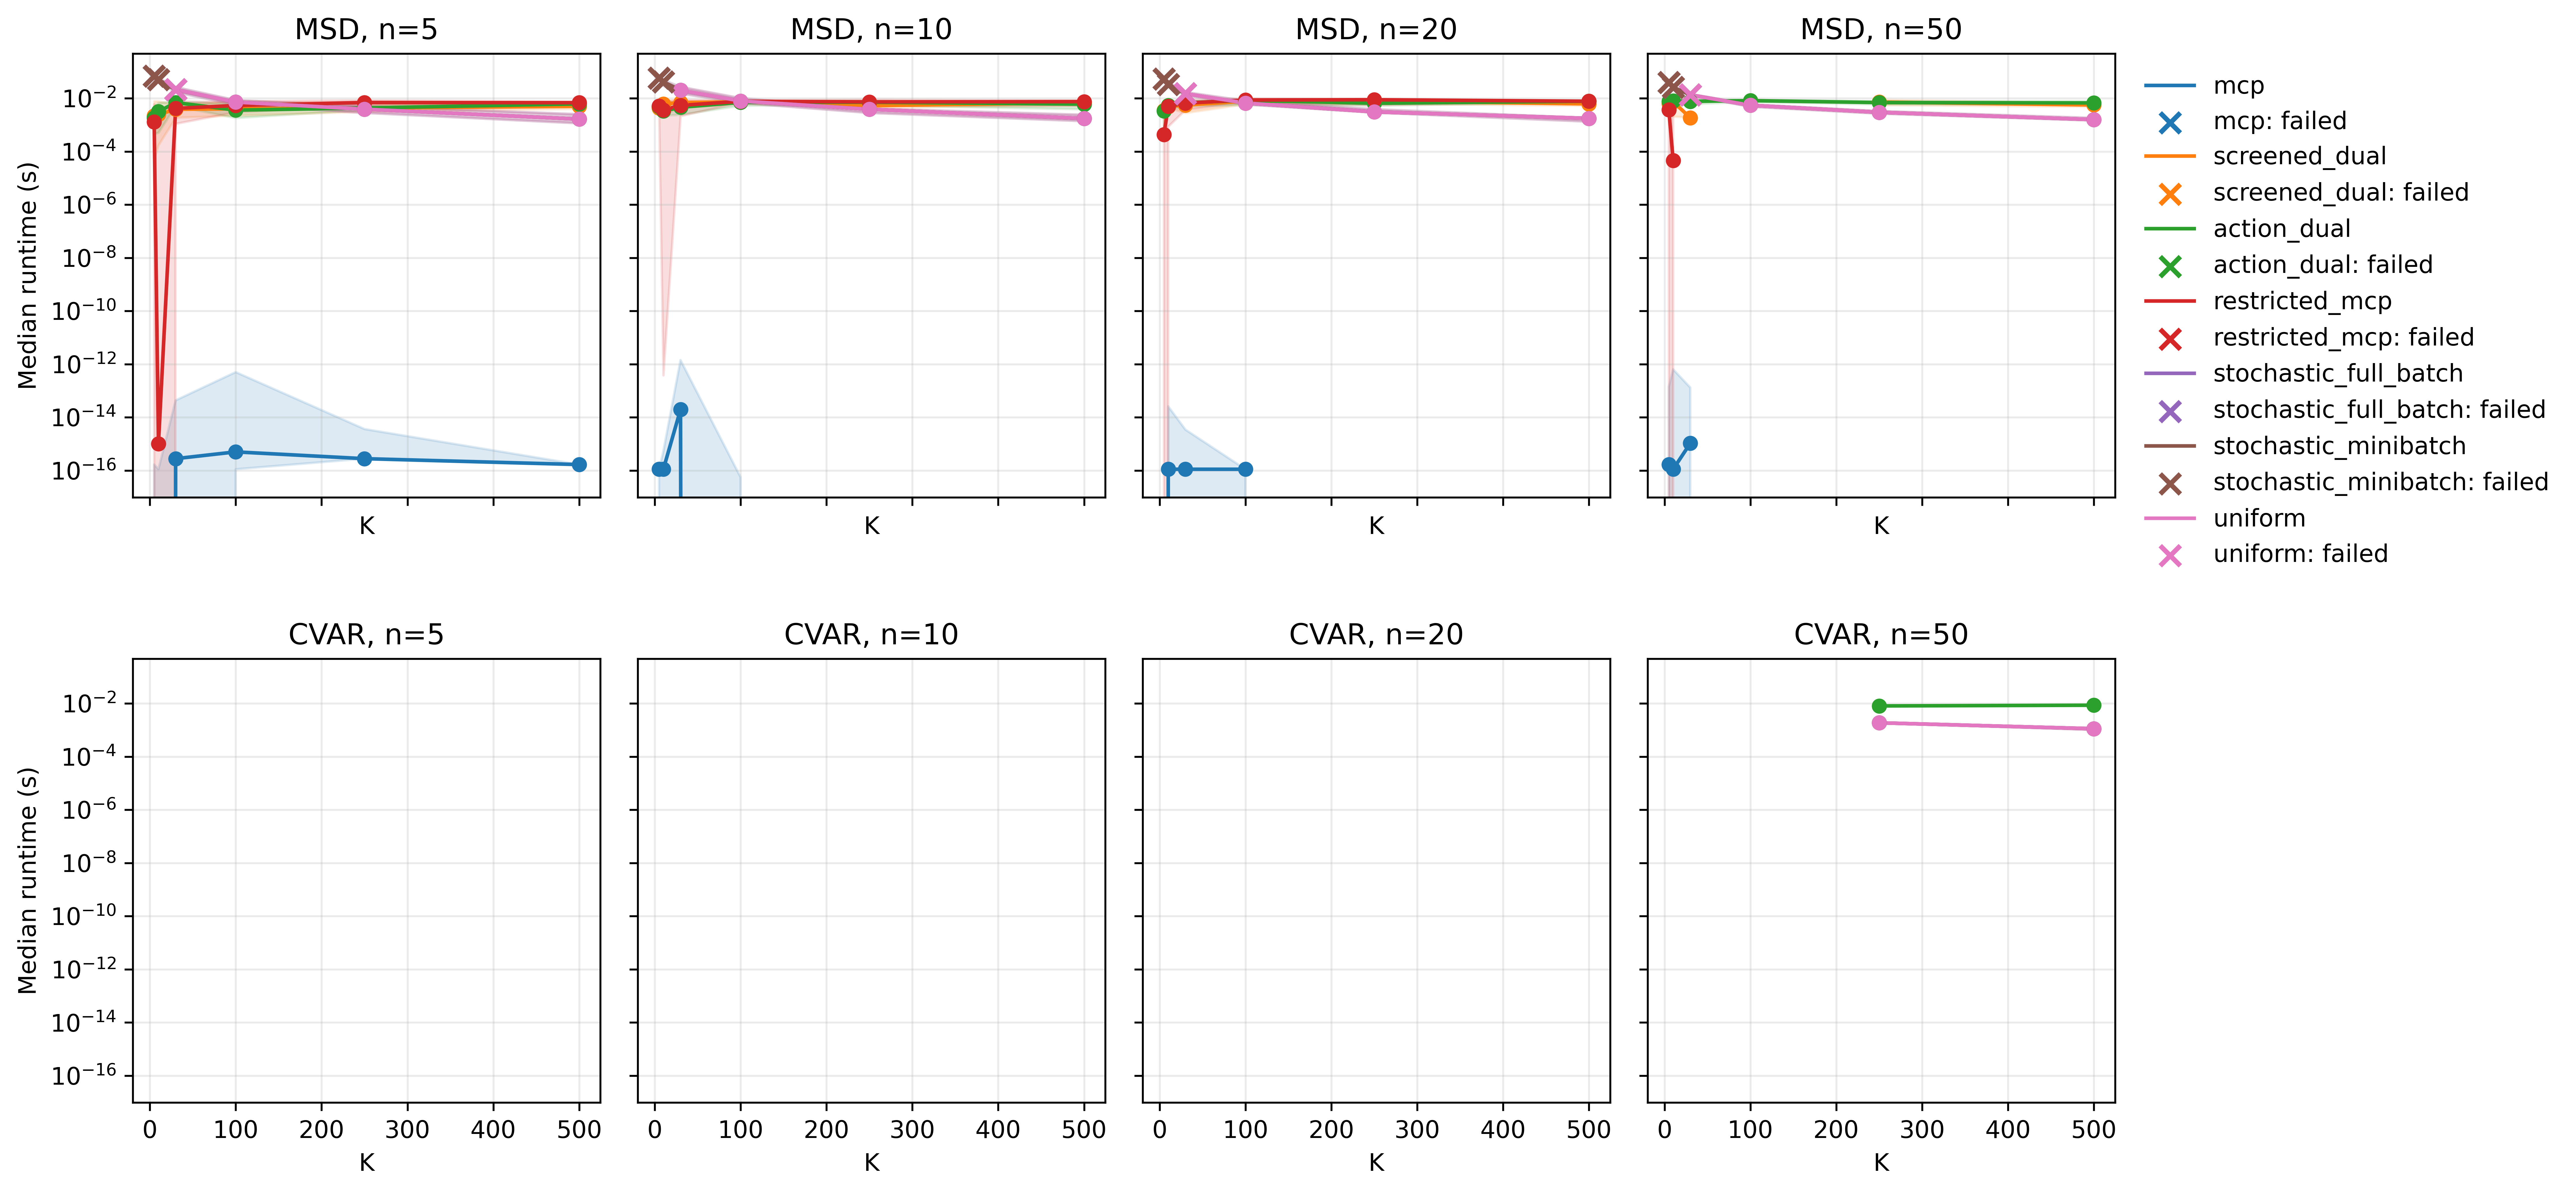

In [148]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False, dropna=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_eta_q25": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_eta_q75": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_eta_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_eta_q25"],
                method_df[f"{method}_eta_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_eta_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_eta_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median runtime (s)")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Stochastic

In [4]:
import pandas as pd

summary = pd.read_csv("results/stochastic/pilot_summary.csv")

In [5]:
summary

,K,n,seed,gamma,entropy_kappa,smoothing_tau,max_iter,minibatch_size,step_size,step_decay,...,minibatch_best_residual_norm,minibatch_best_objective,minibatch_best_certificate_eta,minibatch_best_certificate_iteration,minibatch_error,eta_diff_minibatch_minus_full_batch,residual_diff_minibatch_minus_full_batch,time_ratio_minibatch_over_full_batch,x_l1_minibatch_minus_full_batch,y_l1_minibatch_minus_full_batch
0,30,20,302123,0.5,0.050,0.100,300,6,0.01,0.5,...,0.068872,0.002372,0.014191,300,NaN,-9.066250e-08,-7.907167e-07,0.786557,8.523369e-06,6.551745e-06
1,100,20,1002123,0.5,0.050,0.100,300,10,0.01,0.5,...,0.041639,0.000867,0.009399,300,NaN,-1.563725e-08,-4.044265e-08,0.936306,3.348455e-06,3.704683e-06
2,30,20,302123,0.5,0.050,0.100,300,6,0.05,0.5,...,0.068641,0.002356,0.014178,300,NaN,-4.517977e-07,-3.934257e-06,0.938219,4.253465e-05,3.267249e-05
3,100,20,1002123,0.5,0.050,0.100,300,10,0.05,0.5,...,0.041493,0.000861,0.009394,300,NaN,-7.791426e-08,-1.989932e-07,0.982662,1.670171e-05,1.848047e-05
4,30,20,302123,0.5,0.050,0.100,300,6,0.20,0.5,...,0.067784,0.002297,0.014131,300,NaN,-1.324871e-06,-1.545108e-05,0.966591,1.689116e-04,1.294083e-04
5,100,20,1002123,0.5,0.050,0.100,300,10,0.20,0.5,...,0.040952,0.000839,0.009373,300,NaN,-3.076170e-07,-7.482774e-07,1.027365,6.620253e-05,7.328189e-05
6,30,20,302123,0.5,0.050,0.020,300,6,0.01,0.5,...,0.069329,0.002403,0.014191,300,NaN,-8.998516e-08,-9.768383e-07,0.996578,9.274060e-06,7.096492e-06
7,100,20,1002123,0.5,0.050,0.020,300,10,0.01,0.5,...,0.042024,0.000883,0.009399,300,NaN,-1.380095e-08,1.009699e-07,1.010730,3.778495e-06,3.948520e-06
8,30,20,302123,0.5,0.050,0.020,300,6,0.05,0.5,...,0.069090,0.002387,0.014178,300,NaN,-4.484052e-07,-4.860691e-06,1.001918,4.626898e-05,3.537399e-05
9,100,20,1002123,0.5,0.050,0.020,300,10,0.05,0.5,...,0.041873,0.000877,0.009393,300,NaN,-6.881537e-08,5.054914e-07,1.007385,1.885148e-05,1.970199e-05
